In [18]:
import numpy as np
import matplotlib.pyplot as plt


In [24]:
#Import Data
Frequency, MagS21 = np.loadtxt('Run_2.csv', delimiter = '\t',skiprows=1, unpack=True)
c=3*10**8

In [25]:
#Square MagS21
Sq_MagS21 = MagS21**2

In [26]:
idx = MagS21.argmin()
print(MagS21[idx])
res_f = Frequency[idx]

-0.0701284


In [27]:
def find_effective_permeability(e_r,d,W):
    e_e = ((e_r+1)/(2))+((e_r-1)/(2))*(1/(np.sqrt(1+(12*d/W))))
    return e_e

def find_resonator_frequency(e_r,d,W,l):
    e_e = find_effective_permeability(e_r,d,W)

    f0 = (c/(np.sqrt(e_e)))*(1/(2*l))
    return f0

theo_res_f = find_resonator_frequency(11.6,270*(10**-6),10*(10**-6),12*(10**-3))
theo_res_f = theo_res_f/(10**9)
print(f'{theo_res_f} GHz')

4.867834838432226 GHz


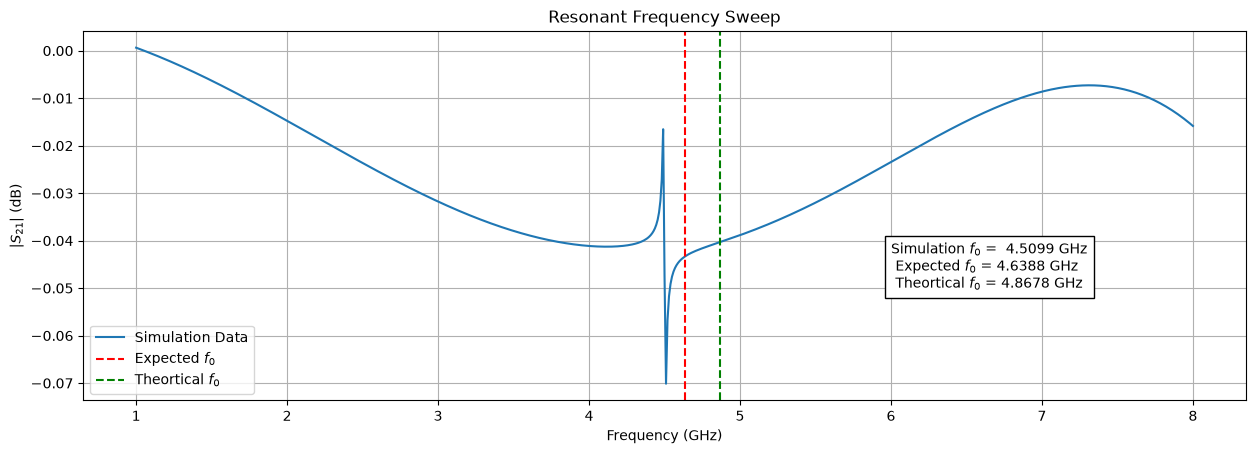

In [31]:
plt.figure().set_figwidth(15)
plt.title('Resonant Frequency Sweep')
plt.xlabel(r'Frequency $(\mathrm{GHz})$')
plt.ylabel(r'$| S_{21} |$ ($\mathrm{dB}$)')
plt.plot(Frequency,MagS21,label = 'Simulation Data')
plt.axvline(x=4.6385,c='r',ls='--',label='Expected $f_0$')
plt.axvline(x=4.8678,c='g',ls='--',label='Theortical $f_0$')
plt.text(6, -0.05, rf'Simulation $f_0$ =  {res_f:.4f} GHz'
         f'\n Expected $f_0$ = 4.6388 GHz'
         f'\n Theortical $f_0$ = {theo_res_f:.4f} GHz ',bbox=dict(facecolor='white', alpha=1))
plt.grid()
plt.legend(loc='best')
plt.show()

## Discussion


In [12]:
idx = MagS21.argmin()
print(MagS21[idx])
print(Frequency[idx])

-0.0701284
4.50989


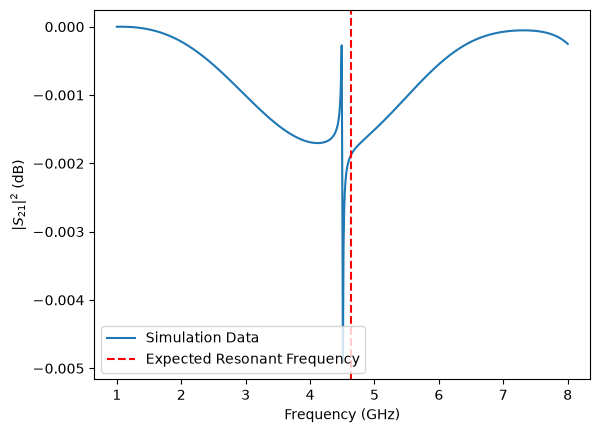

In [23]:
plt.xlabel(r'Frequency $(\mathrm{GHz})$')
plt.ylabel(r'$| S_{21} |^2$ ($\mathrm{dB}$)')
plt.plot(Frequency,-Sq_MagS21,label = 'Simulation Data')
plt.axvline(x=4.6385,c='r',ls='--',label='Expected Resonant Frequency')
plt.legend(loc='best')
plt.show()

In [32]:
percent_error = -((res_f-4.6388)/res_f)*100
print(percent_error)

2.85838457257271
